In [5]:
"""
EE 413 Project
Frequency-Domain Analysis (DFT)
Split: 80% train / 20% test

"""
# The comments in each cell was created with assistance from ChatGPT

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import windows
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.


In [6]:
# 0. CONFIGURATION

DATASET_PATH = "./free-spoken-digit-dataset/recordings"   # path to the FSDD recordings folder
SR           = 8000             # FSDD sample rate (8 kHz)
WINDOW_TYPE  = "hann"           # window function for DFT
RANDOM_STATE = 42               # reproducibility seed

In [7]:
# 1. DATA LOADING

def load_dataset(dataset_path: str):
    """
    Load every .wav file from the FSDD recordings folder.
    FSDD filename format: <digit>_<speaker>_<index>.wav

    Returns
    -------
    signals : list of np.ndarray   raw waveforms (variable length)
    labels  : list of int          digit class (0-9)
    fnames  : list of str          filenames (for debugging)
    """
    signals, labels, fnames = [], [], []

    for fname in sorted(os.listdir(dataset_path)): #return an alphapetical sorted list of our files
        if not fname.endswith(".wav"):
            continue
        digit = int(fname.split("_")[0])           # label from filename
        path  = os.path.join(dataset_path, fname)
        sig, _ = librosa.load(path, sr=SR, mono=True)
        signals.append(sig)
        labels.append(digit)
        fnames.append(fname)

    print(f"Loaded {len(signals)} recordings across {len(set(labels))} classes.")
    return signals, labels, fnames

In [8]:
# 2. PREPROCESSING

def preprocess(signal: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Trim leading/trailing silence and peak-normalize the signal.

    Parameters
    ----------
    signal : raw waveform from librosa.load
    sr     : sample rate

    Returns
    -------
    sig : cleaned, normalized waveform
    """
    # Trim silence (top_db=20 is a standard threshold for clean audio)
    sig, _ = librosa.effects.trim(signal, top_db=20)

    # Peak normalization → amplitude in [-1, 1]
    peak = np.max(np.abs(sig))
    if peak > 0:
        sig = sig / peak
    return sig


In [16]:
# 3. DFT FEATURE EXTRACTION

def compute_dft(signal: np.ndarray, sr: int = SR,
                window_type: str = WINDOW_TYPE):
    """
    Core DFT computation used by all feature and plot functions.

    Steps
    -----
    1. Apply a Hann window  → reduces spectral leakage
    2. Zero-pad to next power of 2  → efficient FFT + smoother spectrum
    3. numpy.fft.rfft  → positive-frequency magnitude spectrum

    Returns
    -------
    freqs     : np.ndarray  frequency axis in Hz
    magnitude : np.ndarray  |X(f)| magnitude spectrum
    power     : np.ndarray  |X(f)|^2 power spectrum
    """
    N     = len(signal)
    win   = windows.get_window(window_type, N)
    windowed = signal * win

    # Next power of 2 for FFT efficiency
    N_fft = int(2 ** np.ceil(np.log2(N)))

    # The following fft algoratim was created with assistance from AI
    # rfft gives only positive frequencies (0 … sr/2)
    spectrum  = np.fft.rfft(windowed, n=N_fft)
    magnitude = np.abs(spectrum)
    power     = magnitude ** 2
    freqs     = np.fft.rfftfreq(N_fft, d=1/sr)

    return freqs, magnitude, power


def extract_dft_features(signal: np.ndarray, sr: int = SR,
                          window_type: str = WINDOW_TYPE) -> np.ndarray:
    """
    Extract 5 spectral features from the full-signal DFT.

    Features
    --------
    1. Spectral Centroid  — weighted average frequency (brightness)
    2. Spectral Bandwidth — spread around the centroid
    3. Spectral Rolloff   — frequency below which 85% of energy lies
    4. Spectral Flux      — energy difference between lower/upper halves
    5. Spectral Flatness  — tonal (0) vs noise-like (1) character

    Returns
    -------
    features : np.ndarray, shape (5,)
    """
    freqs, magnitude, power = compute_dft(signal, sr, window_type)

    if power.sum() == 0:
        return np.zeros(5)

    # 1. Spectral Centroid
    centroid = np.sum(freqs * power) / np.sum(power)

    # 2. Spectral Bandwidth
    bandwidth = np.sqrt(
        np.sum(power * (freqs - centroid) ** 2) / np.sum(power)
    )

    # 3. Spectral Rolloff (85%)
    cumulative  = np.cumsum(power)
    threshold   = 0.85 * cumulative[-1]
    rolloff_idx = np.searchsorted(cumulative, threshold)
    rolloff     = freqs[min(rolloff_idx, len(freqs) - 1)]

    # 4. Spectral Flux (lower half vs upper half energy difference)
    half = len(magnitude) // 2
    flux = np.sum((magnitude[half:half*2] - magnitude[:half]) ** 2)

    # 5. Spectral Flatness (geometric mean / arithmetic mean)
    eps      = 1e-10
    flatness = (np.exp(np.mean(np.log(power + eps))) /
                (np.mean(power) + eps))

    return np.array([centroid, bandwidth, rolloff, flux, flatness])

In [17]:
# 4. BUILD FEATURE MATRIX

# The following matrix code was created with assistance from AI
def build_feature_matrix(signals, labels, sr=SR):
    """
    Run preprocessing + feature extraction on every recording.

    Returns
    -------
    X : np.ndarray, shape (n_samples, 5)
    y : np.ndarray, shape (n_samples,)
    """
    X, y = [], []
    for sig, lbl in zip(signals, labels):
        sig   = preprocess(sig, sr)
        feats = extract_dft_features(sig, sr)
        X.append(feats)
        y.append(lbl)

    X = np.array(X)
    y = np.array(y)

    # Replace any NaN/Inf from silent recordings
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"Feature matrix: {X.shape}  |  Labels: {y.shape}")
    return X, y

In [18]:
# 5. TRAIN / TEST SPLIT & SCALING

def prepare_data(X, y, test_size=0.20, random_state=RANDOM_STATE):
    """
    Stratified 80/20 split + StandardScaler normalization.

    Stratified  → each digit appears proportionally in train and test.
    Scaler      → fit ONLY on training data to prevent data leakage;
                  the same fitted scaler is applied to test data.

    Returns
    -------
    X_train, X_test, y_train, y_test : split arrays
    scaler : fitted StandardScaler (save this if you deploy the model)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)  # fit + transform train
    X_test  = scaler.transform(X_test)       # transform test only

    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    return X_train, X_test, y_train, y_test, scaler

In [19]:
# 6. TRAIN CLASSIFIERS

def train_classifiers(X_train, y_train):
    """
    Train three classifiers on the DFT feature set.
    Training three allows the required comparison analysis.

    Returns
    -------
    clfs : dict {name: fitted_classifier}
    """
    clfs = {
        "KNN (k=5)":     KNeighborsClassifier(n_neighbors=5),
        "SVM (RBF)":     SVC(kernel="rbf", C=10, gamma="scale",
                              random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200,
                                                random_state=RANDOM_STATE),
    }
    for name, clf in clfs.items():
        clf.fit(X_train, y_train)
        print(f"Trained: {name}")
    return clfs


In [20]:
# 7. EVALUATE

# The following evaluation code was created with assistance from AI
def evaluate(clfs, X_test, y_test):
    """
    Print accuracy and per-class report for each classifier.

    Returns
    -------
    results : dict {name: (y_pred, accuracy)}
    """
    results = {}
    for name, clf in clfs.items():
        y_pred = clf.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)
        print(f"\n{'='*52}")
        print(f"  {name}  —  Test Accuracy: {acc:.2%}")
        print(classification_report(
            y_test, y_pred,
            target_names=[str(d) for d in range(10)]
        ))
        results[name] = (y_pred, acc)
    return results


In [21]:
# 8. VISUALIZATIONS


# The following visualization code was created with assistance from AI
def plot_dft_exploration(signal, sr=SR, digit_label=None):
    """
    Figure 1 — DFT deep dive (4 subplots):
      (a) Raw waveform in time domain
      (b) Hann window applied — shows tapering effect
      (c) Spectrum WITHOUT window — spectral leakage visible
      (d) Spectrum WITH window + zero-padding — clean peaks
    """
    N        = len(signal)
    win      = windows.hann(N)
    windowed = signal * win
    t        = np.arange(N) / sr

    N_fft     = int(2 ** np.ceil(np.log2(N)))
    spec_rect = np.abs(np.fft.rfft(signal,   n=N_fft))   # no window
    spec_hann = np.abs(np.fft.rfft(windowed, n=N_fft))   # hann window
    freqs     = np.fft.rfftfreq(N_fft, d=1/sr)

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    title = (f"DFT Exploration — Digit '{digit_label}'"
             if digit_label is not None else "DFT Exploration")
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # (a) Raw waveform
    axes[0, 0].plot(t, signal, color="#1a6bbd", linewidth=0.8)
    axes[0, 0].set_title("(a) Raw waveform — time domain")
    axes[0, 0].set_xlabel("Time (s)")
    axes[0, 0].set_ylabel("Amplitude")

    # (b) Windowed waveform
    axes[0, 1].plot(t, windowed, color="#2ca02c", linewidth=0.8,
                    label="Windowed signal")
    axes[0, 1].plot(t, win * np.max(np.abs(signal)), color="#d62728",
                    linewidth=1.2, linestyle="--", label="Hann window (scaled)")
    axes[0, 1].set_title("(b) Hann window applied")
    axes[0, 1].set_xlabel("Time (s)")
    axes[0, 1].legend(fontsize=8)

    # (c) Spectrum WITHOUT window
    axes[1, 0].plot(freqs, spec_rect, color="#d62728", linewidth=0.8)
    axes[1, 0].set_title("(c) Spectrum — NO window (spectral leakage)")
    axes[1, 0].set_xlabel("Frequency (Hz)")
    axes[1, 0].set_ylabel("|X(f)|")

    # (d) Spectrum WITH Hann + zero-padding
    axes[1, 1].plot(freqs, spec_hann, color="#1a6bbd", linewidth=0.8)
    axes[1, 1].set_title("(d) Spectrum — Hann window + zero-padding")
    axes[1, 1].set_xlabel("Frequency (Hz)")
    axes[1, 1].set_ylabel("|X(f)|")

    plt.tight_layout()
    plt.savefig("fig1_dft_exploration.png", dpi=150)
    plt.show()
    print("Saved: fig1_dft_exploration.png")


def plot_window_comparison(signal, sr=SR, digit_label=None):
    """
    Figure 2 — Effect of different window functions on the spectrum.
    Compares: Rectangular, Hann, Hamming, Blackman.
    """
    N     = len(signal)
    N_fft = int(2 ** np.ceil(np.log2(N)))
    freqs = np.fft.rfftfreq(N_fft, d=1/sr)

    window_types = ["boxcar", "hann", "hamming", "blackman"]
    colors       = ["#d62728", "#1a6bbd", "#2ca02c", "#ff7f0e"]

    fig, ax = plt.subplots(figsize=(10, 5))
    for wtype, color in zip(window_types, colors):
        win     = windows.get_window(wtype, N)
        spec    = np.abs(np.fft.rfft(signal * win, n=N_fft))
        spec_db = 20 * np.log10(spec + 1e-10)
        ax.plot(freqs, spec_db, label=wtype.capitalize(),
                color=color, linewidth=0.9)

    ax.set_title("Window function comparison — spectral leakage effect",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.legend()
    ax.set_ylim(bottom=-80)
    plt.tight_layout()
    plt.savefig("fig2_window_comparison.png", dpi=150)
    plt.show()
    print("Saved: fig2_window_comparison.png")


def plot_zero_padding_effect(signal, sr=SR):
    """
    Figure 3 — Zero-padding demonstration.
    Uses a short 256-sample chunk for visual clarity.
    Shows: same signal, same information, smoother interpolation.
    """
    N     = min(len(signal), 256)
    chunk = signal[:N]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    for ax, factor, color in zip(axes, [1, 4, 16],
                                  ["#d62728", "#1a6bbd", "#2ca02c"]):
        Nz   = N * factor
        win  = windows.hann(N)
        spec = np.abs(np.fft.rfft(chunk * win, n=Nz))
        fz   = np.fft.rfftfreq(Nz, d=1/sr)
        ax.plot(fz, spec, color=color, linewidth=0.9)
        ax.set_title(f"Zero-padding ×{factor}  (N_fft={Nz})",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Frequency (Hz)")
        if factor == 1:
            ax.set_ylabel("|X(f)|")

    fig.suptitle("Effect of Zero-Padding on DFT Spectrum",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig3_zero_padding.png", dpi=150)
    plt.show()
    print("Saved: fig3_zero_padding.png")


def plot_digit_spectra(signals, labels, sr=SR):
    """
    Figure 4 — Average DFT magnitude spectrum per digit (0-9).
    Shows which frequency regions are diagnostic for each class.
    Each subplot averages all recordings of that digit.
    """
    N_fft = 8192
    freqs = np.fft.rfftfreq(N_fft, d=1/sr)

    fig, axes = plt.subplots(2, 5, figsize=(16, 6),
                              sharex=True, sharey=False)
    axes = axes.flatten()

    for digit in range(10):
        ax     = axes[digit]
        sigs_d = [s for s, l in zip(signals, labels) if l == digit]
        specs  = []
        for s in sigs_d:
            s   = preprocess(s, sr)
            N   = len(s)
            win = windows.hann(N)
            sp  = np.abs(np.fft.rfft(s * win, n=N_fft))
            specs.append(sp)
        mean_spec = np.mean(specs, axis=0)
        ax.plot(freqs, mean_spec, linewidth=0.9, color="#1a6bbd")
        ax.fill_between(freqs, mean_spec, alpha=0.25, color="#1a6bbd")
        ax.set_title(f"Digit '{digit}'  (n={len(sigs_d)})", fontsize=10)
        ax.set_xlabel("Frequency (Hz)", fontsize=8)
        ax.set_ylabel("|X(f)|", fontsize=8)

    fig.suptitle("Average DFT Spectrum per Digit",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig4_digit_spectra.png", dpi=150)
    plt.show()
    print("Saved: fig4_digit_spectra.png")


def plot_confusion_matrix(y_test, y_pred, clf_name):
    """
    Figure 5 — Confusion matrix.
    Rows = true digit, Columns = predicted digit.
    Diagonal = correct predictions; off-diagonal = errors.
    """
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {clf_name}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"fig5_confusion_{clf_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")


def plot_classifier_comparison(results):
    """
    Figure 6 — Bar chart comparing test accuracy of all classifiers.
    """
    names = list(results.keys())
    accs  = [results[n][1] * 100 for n in names]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(names, accs,
                  color=["#1a6bbd", "#2ca02c", "#d62728"],
                  edgecolor="white", width=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{acc:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("Classifier Comparison — DFT Features",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig6_classifier_comparison.png", dpi=150)
    plt.show()
    print("Saved: fig6_classifier_comparison.png")

Loaded 3000 recordings across 10 classes.


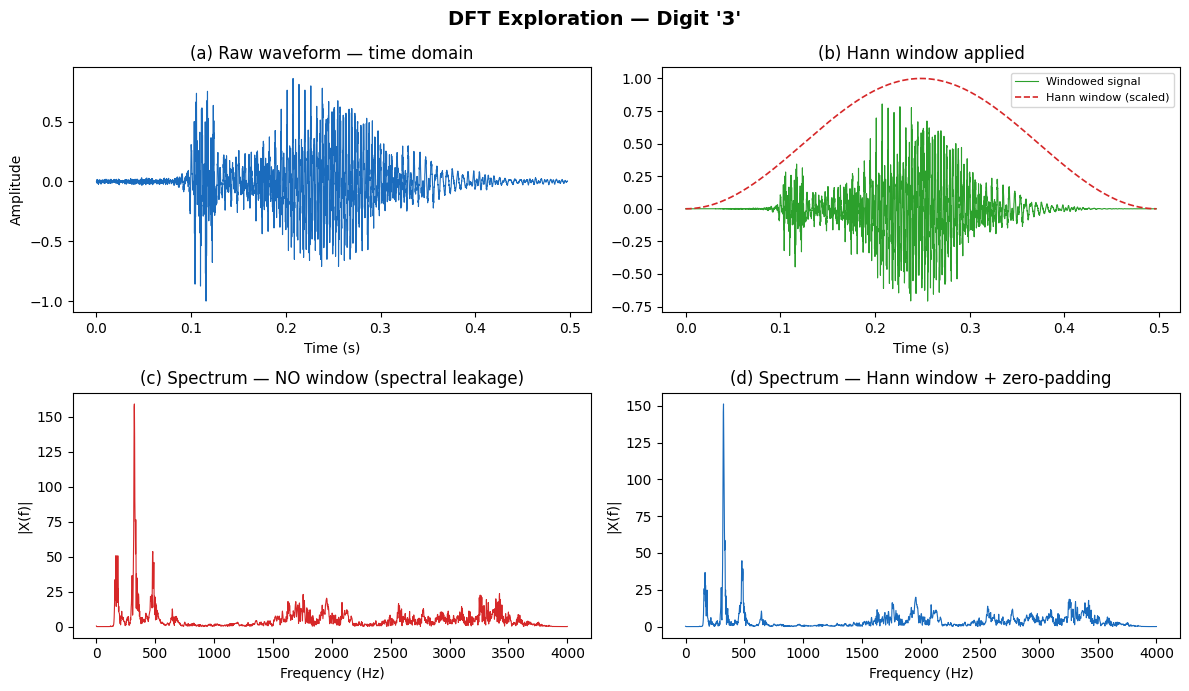

Saved: fig1_dft_exploration.png


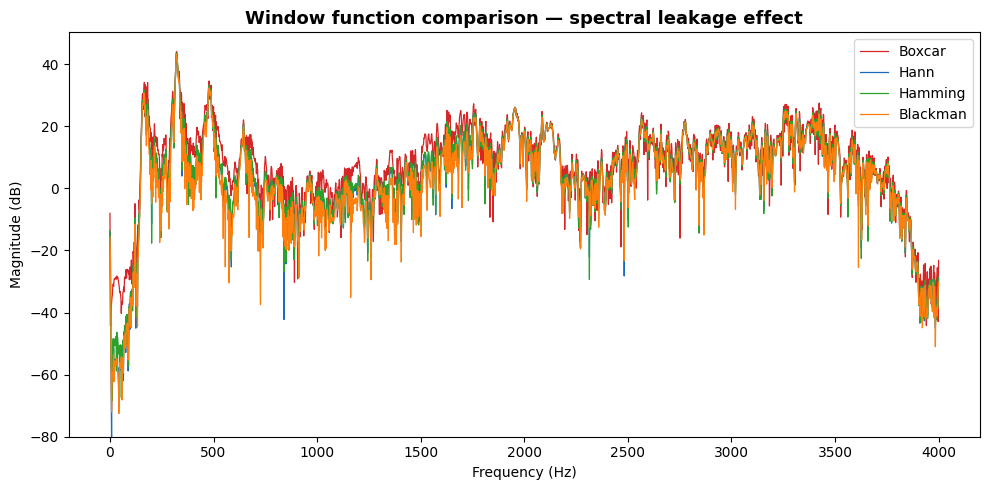

Saved: fig2_window_comparison.png


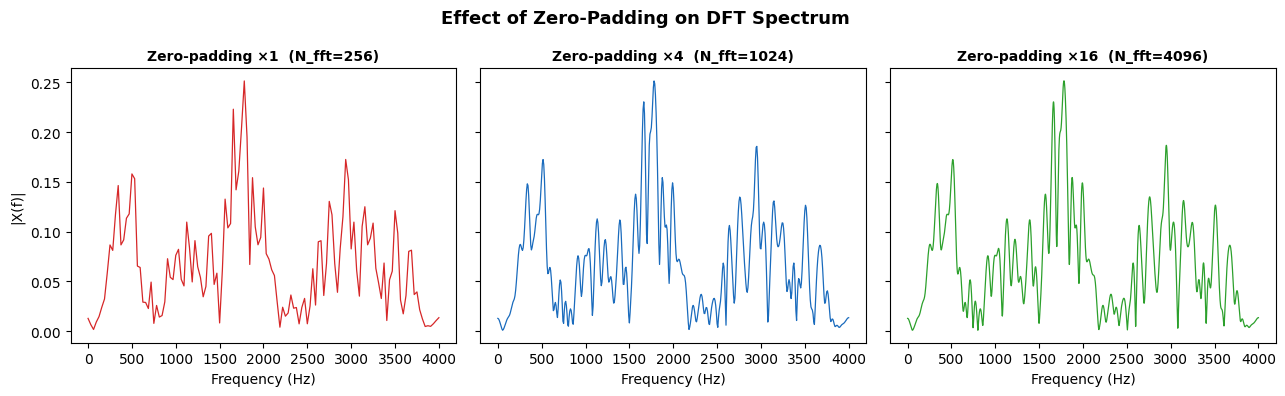

Saved: fig3_zero_padding.png


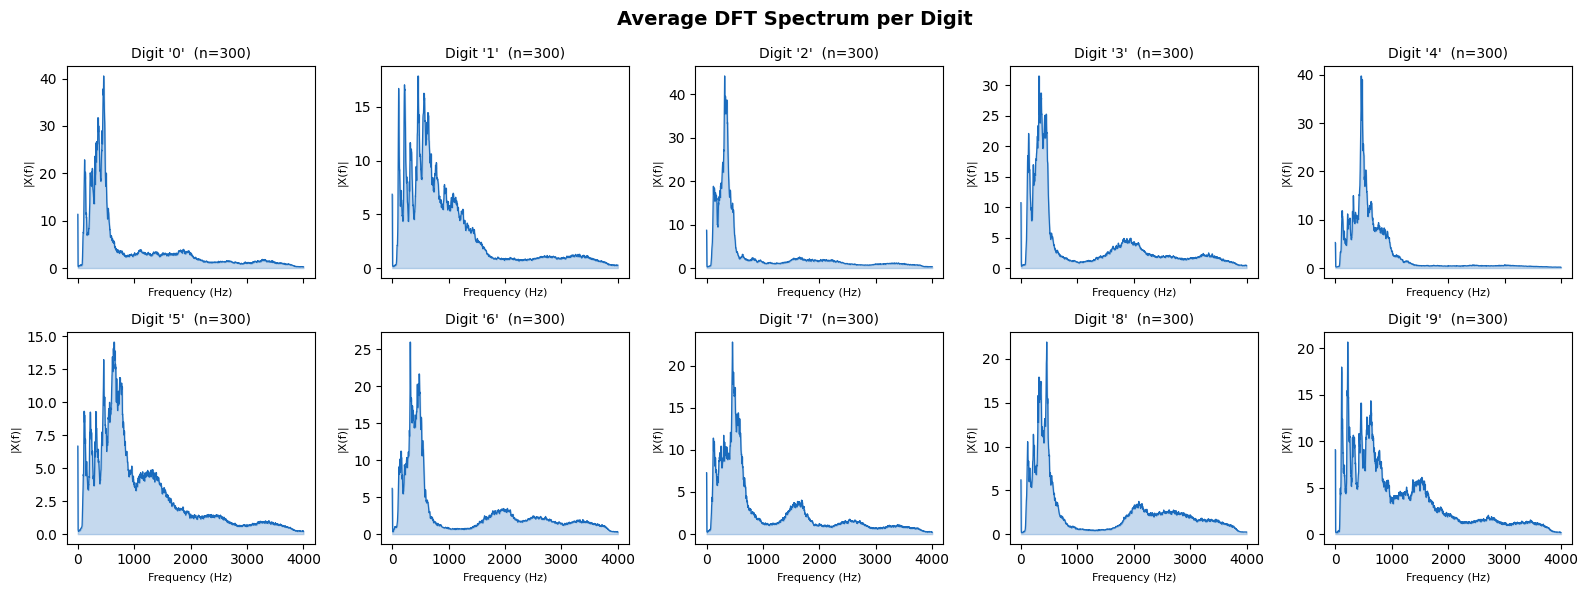

Saved: fig4_digit_spectra.png
Feature matrix: (3000, 5)  |  Labels: (3000,)
Train samples: 2400 | Test samples: 600
Trained: KNN (k=5)
Trained: SVM (RBF)
Trained: Random Forest

  KNN (k=5)  —  Test Accuracy: 57.83%
              precision    recall  f1-score   support

           0       0.51      0.62      0.56        60
           1       0.49      0.53      0.51        60
           2       0.71      0.68      0.69        60
           3       0.51      0.48      0.50        60
           4       0.80      0.75      0.78        60
           5       0.55      0.53      0.54        60
           6       0.50      0.50      0.50        60
           7       0.55      0.58      0.56        60
           8       0.65      0.62      0.63        60
           9       0.56      0.48      0.52        60

    accuracy                           0.58       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.58      0.58      0.58       600


  SVM (RBF)  —  Test Acc

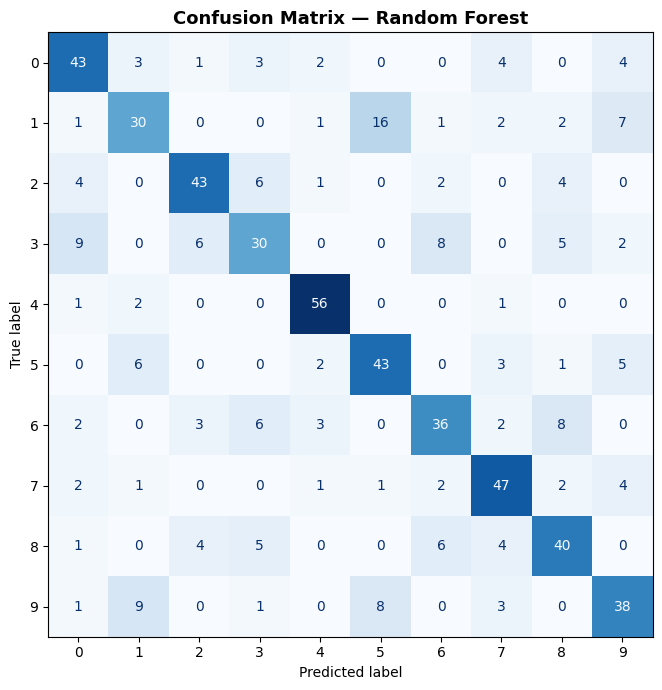

Saved: fig5_confusion_Random_Forest.png


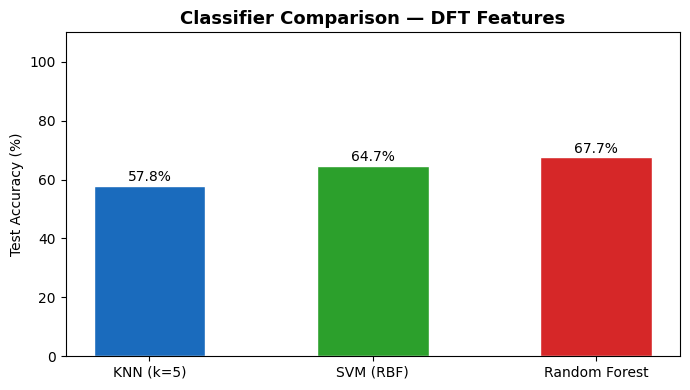

Saved: fig6_classifier_comparison.png

All done. 6 figures saved.


In [22]:
# 9. MAIN PIPELINE

def main():
    # 1. Load dataset
    signals, labels, fnames = load_dataset(DATASET_PATH)

    # 2. Pick one example recording per digit for visualizations
    idx3 = next(i for i, l in enumerate(labels) if l == 3)
    sig3 = preprocess(signals[idx3])

    # 3. Generate exploratory plots
    plot_dft_exploration(sig3, digit_label=3)       # Fig 1
    plot_window_comparison(sig3, digit_label=3)     # Fig 2
    plot_zero_padding_effect(sig3)                  # Fig 3
    plot_digit_spectra(signals, labels)             # Fig 4

    # 4. Build feature matrix (all recordings)
    X, y = build_feature_matrix(signals, labels)

    # 5. Train/test split (80/20 stratified)
    X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

    # 6. Train classifiers
    classifiers = train_classifiers(X_train, y_train)

    # 7. Evaluate
    results = evaluate(classifiers, X_test, y_test)

    # 8. Visualize results
    best_name = max(results, key=lambda n: results[n][1])
    plot_confusion_matrix(y_test, results[best_name][0], best_name)  # Fig 5
    plot_classifier_comparison(results)                               # Fig 6

    print("\nAll done. 6 figures saved.")


if __name__ == "__main__":
    main()